## Nous allons faire cette analyse en répondant à quelques questions métiers dans le sens de l'étude de notre dataset afin de savoir
### Quel est le profil d'un patient ayant un rique élevé de faire un AVC ?
Pour cela, nous allons comparer la population de stroke = 0 et la population de stroke = 1

In [91]:
# Bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [92]:
# Importons notre dataset
df_clean = pd.read_csv("../data/healthcare_stroke_dataset_clean.csv")

display(df_clean.head())

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


#### Quel est le profil moyen des 2 groupes ?

In [93]:
# Nous allons résumé les profils en 2 groupes avec des facteurs précis
profil_stroke = df_clean.groupby("stroke").agg({"age":"mean", 
                                "avg_glucose_level":"mean",
                                  "bmi": "mean",
                                  "hypertension": "mean",
                                  "heart_disease" : "mean"
                                  }).round(3)

profil_stroke

,age,avg_glucose_level,bmi,hypertension,heart_disease
stroke,,,,,
0,41.975,104.788,28.80,0.089,0.047
1,67.728,132.545,30.09,0.265,0.189


### Quels facteurs présentent les plus fortes différences ?
Nous verrons quelles variables changent le plus lorsqu'un patient à l'AVC

In [94]:
profil_stroke.loc[1] - profil_stroke.loc[0]

age                  25.753
avg_glucose_level    27.757
bmi                   1.290
hypertension          0.176
heart_disease         0.142
dtype: float64

Il y a trois facteurs qui ressortent considérablement:

- le facteur `âge` qui domine avec un écart de près de 26 ans.
- le facteur `glycémie`: les patients ayant subi un AVC présentent une glycémie moyenne beaucoup plus élevée. Avec une écart de près de 28 mg/dL.
- le facteur `hypertension` : on a une importance différente 27 % des patients victimes d'un AVC sont hypertendus contre seulement 9 % chez les autres. 

La maladie cardiaque vient juste derrière.

L'IMC semble avoir un effet plus limité.

### Quelle est la répartition de l'AVC selon les catégories ?
#### Gender


In [95]:
pd.crosstab(df_clean["gender"], df_clean["stroke"],normalize="index").round(3)*100

stroke,0,1
gender,,
Female,95.3,4.7
Male,94.9,5.1


La différence est très faible.

Nous dirons que le sexe ne semble pas être un facteur majeur dans ce jeu de données.

#### Mariage

In [96]:
pd.crosstab(df_clean["ever_married"], df_clean["stroke"],normalize="index").round(3)*100

stroke,0,1
ever_married,,
No,98.3,1.7
Yes,93.4,6.6


Nous dirions à première vue que les personnes mariées semblent présenter davantage d'AVC.

Cette observation nous amènera à la confusion car les personnes mariées sont en moyenne plus âgées.

Et nous savons déjà que : l'âge est LE principal facteur.

Donc ici on parle probablement d'un facteur de confusion.

#### Type d'emploi

In [97]:
pd.crosstab(df_clean["work_type"], df_clean["stroke"] , normalize="index").round(3)*100

stroke,0,1
work_type,,
Govt_job,95.0,5.0
Never_worked,100.0,0.0
Private,94.9,5.1
Self-employed,92.1,7.9
children,99.7,0.3


Nous dirions à première vue que les travailleurs indépendants semblent présenter davantage d'AVC.

N'oublions pas que les travailleurs indépendants sont souvent plus âgés.

Il est donc probable que l'âge explique une partie de cette différence.

Certainement un autre un facteur de confusion

#### Tabagisme

In [98]:
pd.crosstab(df_clean["smoking_status"], df_clean["stroke"] , normalize="index").round(3)*100

stroke,0,1
smoking_status,,
Unknown,97.0,3.0
formerly smoked,92.1,7.9
never smoked,95.2,4.8
smokes,94.7,5.3


Le taux d'AVC le plus élevé est observé chez les anciens fumeurs (7,9 %).

En revanche, n'oublions qui dit ancien fumeur dit plus âgé que les autres catégories.

Une analyse multivariée serait nécessaire pour isoler l'effet propre du tabagisme.

#### Résidence

In [99]:
pd.crosstab(df_clean["Residence_type"], df_clean["stroke"],normalize="index").round(3)*100

stroke,0,1
Residence_type,,
Rural,95.5,4.5
Urban,94.8,5.2


Nous avons une très faible différence entre les 2 groupes.

Le type de résidence ne semble pas fortement associé à la survenue d'un AVC dans ce jeu de données.

### Pour répondre à notre question du profil d'une personne susceptible de faire un AVC
#### Nous classerions nos facteurs de risques observés ainsi selon leur importance :
Si je devais faire un classement des facteurs observés :

- Âge
- Glycémie
- Hypertension
- Maladie cardiaque
- Tabagisme
- IMC
- Sexe
- Résidence

### Tableau de synthèse

In [100]:
df_clean.columns


Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [101]:
# Réalisons notre tableau de synthèse
table_synthese = pd.DataFrame({"Facteur" : ["Âge moyen", "Glycémie moyenne", "IMC moyen", "Hypertension", "Maladie Cardiaque" ],
  
  "Sans AVC" : [profil_stroke.loc[0, "age"], profil_stroke.loc[0, "avg_glucose_level"] , 
                profil_stroke.loc[0, "bmi"], f"{profil_stroke.loc[0, "hypertension"]*100:.0f} %", 
                f"{profil_stroke.loc[0, "heart_disease"]*100:.0f} %"],

  "Avec AVC" : [profil_stroke.loc[1, "age"], profil_stroke.loc[1, "avg_glucose_level"] , 
                profil_stroke.loc[1, "bmi"], f"{profil_stroke.loc[1, "hypertension"]*100:.0f} %", 
                f"{profil_stroke.loc[1, "heart_disease"]*100:.0f} %"],

  "Écart": [ round(profil_stroke.loc[1, "age"]           -    profil_stroke.loc[0, "age"],2),
        round(profil_stroke.loc[1, "avg_glucose_level"]  -    profil_stroke.loc[0, "avg_glucose_level"],2),
        round(profil_stroke.loc[1, "bmi"]                -    profil_stroke.loc[0, "bmi"],2),
        f" + {round((profil_stroke.loc[1,"hypertension"]   -    profil_stroke.loc[0,"hypertension"])*100,1)} pts",
        f" + {round((profil_stroke.loc[1,"heart_disease"]  -    profil_stroke.loc[0,"heart_disease"])*100,1)} pts"],

"Interprétation": [
        "Association très forte",
        "Association forte",
        "Association faible",
        "Association forte",
        "Association forte" ]
})

display(table_synthese)


,Facteur,Sans AVC,Avec AVC,Écart,Interprétation
0,Âge moyen,41.975,67.728,25.75,Association très forte
1,Glycémie moyenne,104.788,132.545,27.76,Association forte
2,IMC moyen,28.8,30.09,1.29,Association faible
3,Hypertension,9 %,26 %,+ 17.6 pts,Association forte
4,Maladie Cardiaque,5 %,19 %,+ 14.2 pts,Association forte


## Synthèse Analytique et d'interprétation 

In [102]:
# Tableau de synthèse des principaux facteurs associés à l'AVC
table_facteurs = pd.DataFrame({"Facteurs" : ["Âge", 
                                             "Glycémie",
                                             "Hypertension",
                                             "Maladie Cardiaque",
                                             "IMC",
                                             "Tabagisme",
                                             "Sexe",
                                             "Residence",
                                             "Situation Matrimoniale"],
                                "Observations" : [ "+25.6 ans", 
                                                  "+27,75 mg/dL",
                                                  "27 % vs 9 %",
                                                  "19 % vs 5 %",
                                                  "+1.29",
                                                  "7.9 % chez les anciens fumeurs",
                                                  "5.1 % vs 4.7 %",
                                                  "5.2 % vs 4.5 %",
                                                  "6.6 % vs 1.7 %"],
                                "Niveau d'Association" : ["*****",
                                                          "****",
                                                          "****",
                                                          "****",
                                                          "**",
                                                          "**",
                                                          "*",
                                                          "*",
                                                          "**"
                                                            ],
                                "Interprétation" : [ "Facteur fortement associé au risque d'AVC",

        "Glycémie moyenne plus élevée chez les patients AVC",

        "Plus importante chez les patients AVC",

        "Plus fréquentes chez les patients AVC",

        "Différence faible",

        "Association observée mais probablement influencée par l'âge",

        "Différence très faible",

        "Aucune différence majeure observée",

        "Résultat probablement lié à l'âge"
    ]

})

display(table_facteurs)

,Facteurs,Observations,Niveau d'Association,Interprétation
0,Âge,+25.6 ans,*****,Facteur fortement associé au risque d'AVC
1,Glycémie,"+27,75 mg/dL",****,Glycémie moyenne plus élevée chez les patients...
2,Hypertension,27 % vs 9 %,****,Plus importante chez les patients AVC
3,Maladie Cardiaque,19 % vs 5 %,****,Plus fréquentes chez les patients AVC
4,IMC,+1.29,**,Différence faible
5,Tabagisme,7.9 % chez les anciens fumeurs,**,Association observée mais probablement influen...
6,Sexe,5.1 % vs 4.7 %,*,Différence très faible
7,Residence,5.2 % vs 4.5 %,*,Aucune différence majeure observée
8,Situation Matrimoniale,6.6 % vs 1.7 %,**,Résultat probablement lié à l'âge


In [103]:
# nous allons sauvegarder notre table d'analyse
table_facteurs.to_csv("../data/table_synthese_facteurs.csv", index=False)

In [104]:
table_facteurs.shape

(9, 4)

## Quelques visualisations


### Figure 1: Âge moyen

In [105]:
# âge moyen selon le statut AVC
age_mean = df_clean.groupby("stroke")["age"].mean().round(2)
age_mean

stroke
0    41.97
1    67.73
Name: age, dtype: float64

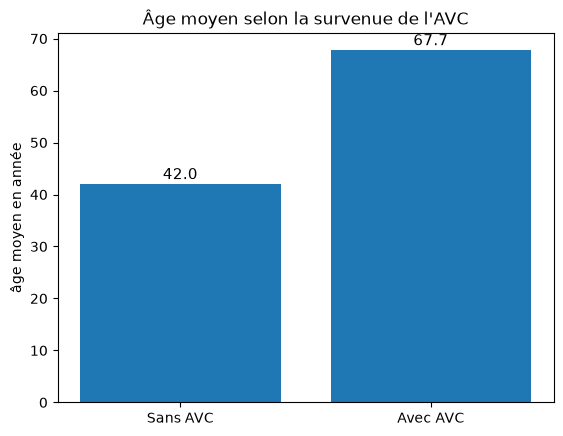

In [106]:
# Figure
plt.Figure(figsize=(8,5))
plt.bar(["Sans AVC", "Avec AVC"], age_mean)
plt.title("Âge moyen selon la survenue de l'AVC")
plt.ylabel("âge moyen en année")
for i, value in enumerate(age_mean):
    plt.text(i, value+1, f"{value:.1f}", ha="center", fontsize=11)

plt.show()

Les patients ayant subi un AVC présentent un âge moyen nettement supérieur à celui des autres patients.

### Figure 2: Glycémie moyenne

In [107]:
# glycémie moyenne selon le statut AVC
glycemie_moyenne = df_clean.groupby("stroke")["avg_glucose_level"].mean().round(2)
glycemie_moyenne

stroke
0    104.79
1    132.54
Name: avg_glucose_level, dtype: float64

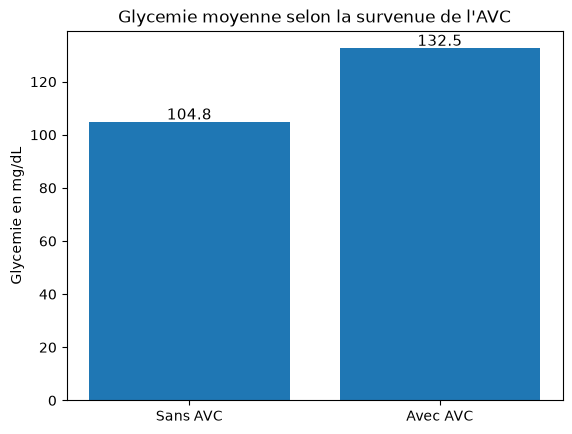

In [108]:
# Figure
plt.Figure(figsize=(6,5))
plt.bar(["Sans AVC", "Avec AVC"], glycemie_moyenne)
plt.title("Glycemie moyenne selon la survenue de l'AVC")
plt.ylabel("Glycemie en mg/dL")
for i, value in enumerate(glycemie_moyenne):
    plt.text(i, value+1, f"{value:.1f}", ha="center", fontsize=11)

plt.show()

### Figure 3 : Prévalence de l'hypertension

In [109]:
# Prévalence de l'hypertension selon le statut AVC
hypert = df_clean.groupby("stroke")["hypertension"].mean()*100
hypert

stroke
0     8.888889
1    26.506024
Name: hypertension, dtype: float64

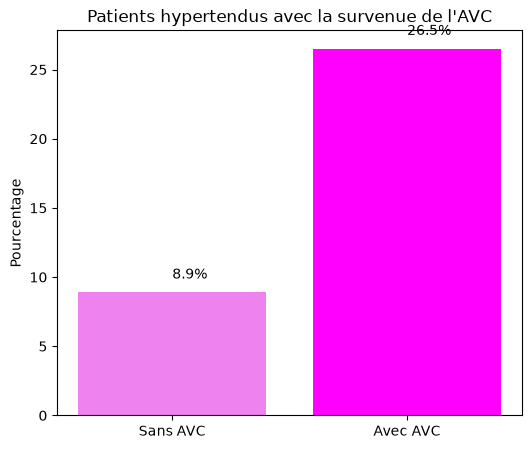

In [110]:
# Figure
plt.figure(figsize=(6,5))
plt.bar(["Sans AVC", "Avec AVC"], hypert, color=["violet", "magenta"])
plt.title("Patients hypertendus avec la survenue de l'AVC")
plt.ylabel("Pourcentage")
for i,value in enumerate(hypert) :
    plt.text(i, value+1, f"{value:.1f}%")

plt.show()

### Figure 4 : Prévalence des maladies cardiaques

In [111]:
df_clean.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [112]:
# Prévalence des maladies cardiaques selon le statut AVC
mal_car = df_clean.groupby("stroke")["heart_disease"].mean()*100
mal_car

stroke
0     4.711934
1    18.875502
Name: heart_disease, dtype: float64

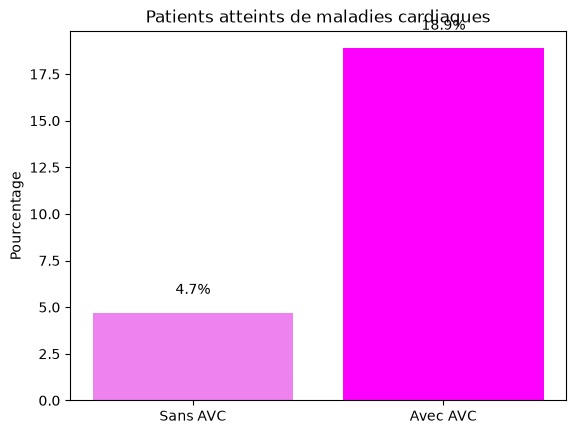

In [113]:
# Figure
plt.Figure(figsize=(6,5))
plt.bar(["Sans AVC", "Avec AVC"], mal_car, color = ["violet", "magenta"])
plt.title("Patients atteints de maladies cardiaques")
plt.ylabel("Pourcentage")

for i, value in enumerate(mal_car):
    plt.text(i, value+1, f"{value:.1f}%", ha="center")

plt.show()

### Figure 5: Taux d'AVC selon le Tabagisme

In [114]:
tabag = (
    pd.crosstab(
        df_clean["smoking_status"],
        df_clean["stroke"],
        normalize="index"
    )[1]*100
)

tabag = tabag.sort_values(ascending=False)
tabag

smoking_status
formerly smoked    7.918552
smokes             5.323194
never smoked       4.756871
Unknown            3.044041
Name: 1, dtype: float64

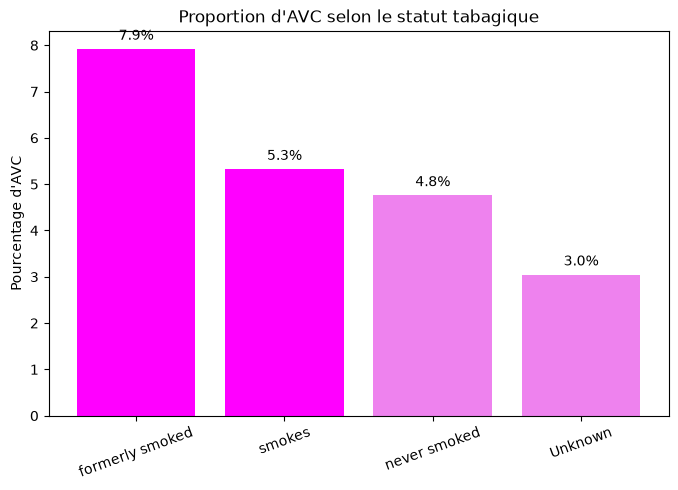

In [115]:

# Figure
plt.figure(figsize=(8,5))
plt.bar(tabag.index, tabag.values, color = ["magenta","magenta", "violet", "violet"])

plt.title("Proportion d'AVC selon le statut tabagique")
plt.ylabel("Pourcentage d'AVC")

for i, value in enumerate(tabag):
    plt.text(i, value+0.2, f"{value:.1f}%", ha="center")

plt.xticks(rotation=20)

plt.show()

Pour répondre à cette question: 
Quels sont les principaux facteurs associés au risque d'AVC dans cette population ?
via Power BI, nous allons préparer les tables.

In [125]:
# Table KPI
table_kpi = pd.DataFrame({"Total patients" : [len(df_clean)],
                          
                          "Nombre patients AVC" : [df_clean["stroke"].sum()],
                          "Taux AVC (%)" : [round(df_clean["stroke"].mean()*100,2)],
                          "Âge moyen" : [round(df_clean["age"].mean(),2)],
                          "Glycémie moyenne" : [round(df_clean["avg_glucose_level"].mean(),2)],
                          "IMC Moyen" : [round(df_clean["bmi"].mean(),2)]
                            })
display(table_kpi)

,Total patients,Nombre patients AVC,Taux AVC (%),Âge moyen,Glycémie moyenne,IMC Moyen
0,5109,249,4.87,43.23,106.14,28.86


In [126]:
table_kpi.to_csv("../data/table_kpi.csv", index=False)

In [128]:
# Créer les classes d'âge
bins = [0,20,40,60,80,100]
labels = [ "0 - 20 ans",
         "21 - 40 ans",
         "41 - 60 ans",
         "61 - 80 ans",
         "81 ans et +"]
df_clean["Classe_age"] = pd.cut(
                                df_clean["age"],
                                bins = bins,
                                labels=labels,
                                include_lowest= False
)

In [130]:
df_clean.head(3)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,Classe_age
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,61 - 80 ans
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,61 - 80 ans
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,61 - 80 ans


In [140]:
# Construire la table de classe d'âge 
table_age = df_clean.groupby("Classe_age").agg(Nombre_patients=("stroke","count"),
                                    Nombre_AVC=("stroke","sum"),
                                    Taux_AVC=("stroke","mean")).reset_index()
table_age

,Classe_age,Nombre_patients,Nombre_AVC,Taux_AVC
0,0 - 20 ans,1025,2,0.001951
1,21 - 40 ans,1218,6,0.004926
2,41 - 60 ans,1562,64,0.040973
3,61 - 80 ans,1188,154,0.129630
4,81 ans et +,116,23,0.198276


In [142]:
# Mettre les valeux du taux AVC en pourcentage
table_age["Taux_AVC"]=(table_age["Taux_AVC"]*100).round(2)
table_age

,Classe_age,Nombre_patients,Nombre_AVC,Taux_AVC
0,0 - 20 ans,1025,2,0.20
1,21 - 40 ans,1218,6,0.49
2,41 - 60 ans,1562,64,4.10
3,61 - 80 ans,1188,154,12.96
4,81 ans et +,116,23,19.83


In [143]:
# sauvegarder notre table_age
table_age.to_csv("../data/table_age.csv", index=False)

In [147]:
# Créer la table des genres et leurs effectifs
table_genre = pd.DataFrame({"Genre": df_clean["gender"].value_counts().index,
              "Effectif_genre": df_clean["gender"].value_counts().values})
table_genre

,Genre,Effectif_genre
0,Female,2994
1,Male,2115


In [148]:
table_genre.to_csv("../data/table_genre.csv", index=False)